In [1]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import pygris

import geopandas as gpd
import pickle 

pd.set_option('display.max_rows', 50)
pd.options.mode.chained_assignment = None


In [2]:
def convert_tract_to_fips(tract_id):
    tract_str = str(tract_id).strip()

    if "." in tract_str:
        before_decimal, after_decimal = tract_str.split(".")
        before_decimal = before_decimal.zfill(4)
        after_decimal = after_decimal.ljust(2, "0")
    else:
        before_decimal = tract_str.zfill(4)
        after_decimal = "00"

    # THIS IS 'PROPER', REMOVING THE LEADING FIPS CODE TO JOIN WITH OTHER DATASETS
    # return f"39035{before_decimal}{after_decimal}"
    return f"{before_decimal}{after_decimal}"

In [3]:
tract_cols = [
    'NAME',
    'ALAND',
    'AWATER',
    'geometry',
]

# Downloading 2010 and 2020 tracts for Cuyahoga County, Ohio.
tracts_2010 = pygris.tracts(state="39", county="035", year=2015)[tract_cols]
tracts_2020 = pygris.tracts(state="39", county="035", year=2020)[tract_cols]

tracts_2010['NAME'] = tracts_2010['NAME'].astype(str).apply(convert_tract_to_fips)
tracts_2020['NAME'] = tracts_2020['NAME'].astype(str).apply(convert_tract_to_fips)

# Excluding tract 9900, which represents a water geometry over lake erie
tracts_2010 = tracts_2010[tracts_2010['NAME'] != '9900']
tracts_2020 = tracts_2020[tracts_2020['NAME'] != '9900']

There are 381 tract names in 2010 that match with 2020. However, there are over 60 tracts that are not accounted for within this. Additionally within the 381 tracts that do match in names, there are some that have grown in area.

In [4]:
count_overlap = 0
for i in tracts_2010["NAME"].unique():
    if i in tracts_2020["NAME"].unique():
        count_overlap += 1
count_overlap

382

In [5]:
tracts_allign_df = pd.DataFrame(columns=['NAME_10','NAME_20','OL_PROP'])

# Function handling the calculation of the overlap area
ol_area_fn = lambda intersect_row: (row.geometry.intersection(intersect_row.geometry).area / row.geometry.area)

for i in range(tracts_2020.shape[0]):
    row = tracts_2020.iloc[i]
    intersect = tracts_2010[tracts_2010.geometry.intersects(row.geometry)]

    intersect['NAME_20'] = row['NAME']
    intersect['OL_PROP'] = intersect.apply(ol_area_fn, axis=1)
    intersect = intersect.drop(columns=['geometry','ALAND','AWATER']).rename(columns={'NAME': 'NAME_10'})
    intersect = intersect[intersect['OL_PROP'] > 0.08]

    tracts_allign_df = pd.concat([tracts_allign_df, intersect])


# TODO handle this special case, it is a tract that is fully within another tract and is absorbed (merged)
# Adding a found special case to the dataframe
# tracts_allign_df.loc[len(tracts_allign_df)] = ['1948', '1971', 1.0]

C:\Users\ethan\AppData\Local\Temp\ipykernel_23908\3295383598.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  tracts_allign_df = pd.concat([tracts_allign_df, intersect])


In [6]:
close_allign_df = tracts_allign_df[tracts_allign_df['OL_PROP'] > 0.9]

In [7]:
# Get rows with name_10 duplicates
dupe_drop_idx = close_allign_df[close_allign_df.duplicated('NAME_10', keep=False)].index
# Drop indexes
close_allign_df = close_allign_df.drop(dupe_drop_idx)

In [8]:
print('all','10','20')
close_allign_df.shape, close_allign_df['NAME_10'].unique().shape, close_allign_df['NAME_20'].unique().shape,

all 10 20


((382, 3), (382,), (382,))

In [9]:
# create a dict of 2010 to 2020 from name_10 and name_20
tracts_dict = dict(zip(close_allign_df['NAME_10'], close_allign_df['NAME_20']))
list(tracts_dict.items())[:10]

[('195900', '195900'),
 ('109301', '109301'),
 ('109801', '109801'),
 ('196200', '196200'),
 ('196300', '196300'),
 ('981100', '981100'),
 ('195700', '195700'),
 ('980100', '980100'),
 ('138106', '138106'),
 ('107701', '107701')]

In [10]:
# save as a pickle file
with open('data/pickle_files/close_enough.pickle', 'wb') as handle:
    pickle.dump(tracts_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
# nt_assign_df = tracts_allign_df.copy()
# # add '01' to name_10 and '02' to name_20
# nt_assign_df['NAME_10'] = nt_assign_df['NAME_10'].apply(lambda x: x + '01')
# nt_assign_df['NAME_20'] = nt_assign_df['NAME_20'].apply(lambda x: x + '02')
# nt_assign_df.reset_index(drop=True, inplace=True)
# nt_assign_df['NTID'] = nt_assign_df.index

# nt_assign_df = pd.concat([nt_assign_df[['NAME_10', 'NTID']].rename(columns={'NAME_10': 'NAME'}), 
#                                      nt_assign_df[['NAME_20', 'NTID']].rename(columns={'NAME_20': 'NAME'})], 
#                                     axis=0).reset_index(drop=True)
# nt_assign_df.sort_values(by='NTID')
# # read 'data\ohio_census_data.csv'
# census_data = pd.read_csv('data/ohio_census_data.csv')[['NAME','tract','year']]

# census_data['tract'] = census_data.apply(lambda x: str(x['tract']) + '01' if x['year'] < 2020 else str(x['tract']) + '02', axis=1)
# census_data['NTID'] = ''

# census_data.head()

,NAME,NTID
0,19590001,0
456,19590002,0
1,10930101,1
457,10930102,1
2,10980101,2
...,...,...
453,12350201,453
910,10240202,454
454,10240201,454
455,15510201,455


In [50]:
# Set ntid to the index

In [51]:
# Count the number of ol_prop with imperfect allignment but less than 2 % difference
tracts_allign_df[(tracts_allign_df['OL_PROP'] > 0.98) & (tracts_allign_df['OL_PROP'] < 0.999)].shape[0]

96

(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,  1.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,
         1.,  0.,  1.,  0.,  1.,  0.,  0.,  0.,  0.,  1.,  0.,  1.,  2.,
         2.,  1.,  5.,  4.,  4.,  8., 10.,  7., 14., 16., 23.]),
 array([0.9218125 , 0.92335518, 0.92489787, 0.92644055, 0.92798324,
        0.92952593, 0.93106861, 0.9326113 , 0.93415398, 0.93569667,
        0.93723936, 0.93878204, 0.94032473, 0.94186741, 0.9434101 ,
        0.94495279, 0.94649547, 0.94803816, 0.94958084, 0.95112353,
        0.95266622, 0.9542089 , 0.95575159, 0.95729427, 0.95883696,
        0.96037965, 0.96192233, 0.96346502, 0.96500771, 0.96655039,
        0.96809308, 0.96963576, 0.97117845, 0.97272114, 0.97426382,
        0.97580651, 0.97734919, 0.97889188, 0.98043457, 0.98197725,
        0.98351994, 0.98506262, 0.98660531, 0.988148  , 0.98969068,
        0.99123337, 0.99277605, 0.99431874, 0.99586143, 0.99740411,
        0.9989468 ]),
 <BarContainer

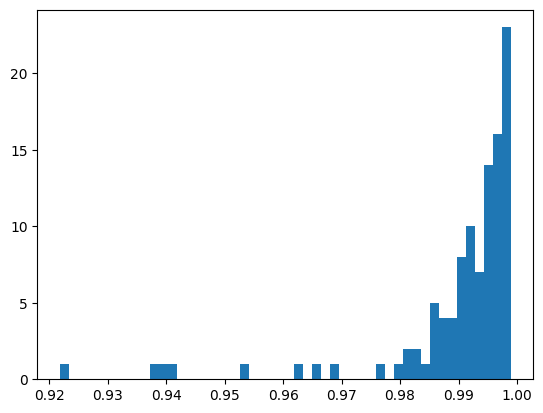

In [52]:
# Generate a histogram of olprop for values > 0.9 but less than 1.0
plt.hist(tracts_allign_df[(tracts_allign_df['OL_PROP'] > 0.9) & (tracts_allign_df['OL_PROP'] < .999)]['OL_PROP'], bins=50)

In [53]:
tracts_allign_df['NAME_10'].value_counts().head(50)

NAME_10
136102    2
172103    2
190504    2
117202    2
131102    2
160601    2
175104    2
107101    2
101200    2
175103    2
122100    1
189107    1
123400    1
122200    1
188106    1
189108    1
189110    1
189105    1
195900    1
188103    1
190502    1
187106    1
187105    1
121900    1
121800    1
121700    1
121500    1
121200    1
121100    1
120801    1
120400    1
120200    1
121300    1
189111    1
123501    1
190503    1
119100    1
141700    1
140100    1
171206    1
120600    1
106300    1
106400    1
110801    1
110501    1
118700    1
104900    1
123100    1
104600    1
104300    1
Name: count, dtype: int64

In [54]:
# Get number of unique 2010 and 2020 tracts
num_2010 = len(tracts_allign_df['NAME_10'].unique())
num_2020 = len(tracts_allign_df['NAME_20'].unique())

print(num_2010,num_2020)
print(tracts_2010['NAME'].unique().shape[0],tracts_2020['NAME'].unique().shape[0])

446 428
447 428


In [55]:
tracts_2010_that_dont_merge = tracts_allign_df['NAME_10'].value_counts()
lst_tracts_2010_good = list(tracts_2010_that_dont_merge[tracts_2010_that_dont_merge == 1].index)

In [56]:
tracts_2020_that_dont_merge = tracts_allign_df['NAME_20'].value_counts()
lst_tracts_2020_good = list(tracts_2020_that_dont_merge[tracts_2020_that_dont_merge == 1].index)

In [57]:
tracts_2010.head()

,NAME,ALAND,AWATER,geometry
245,103602,2306188,1346696,"POLYGON ((-81.73036 41.49212, -81.73032 41.494..."
348,189108,7264427,0,"POLYGON ((-81.96998 41.41638, -81.96998 41.416..."
349,190503,1766959,0,"POLYGON ((-81.93436 41.38447, -81.93435 41.385..."
350,189110,6235650,0,"POLYGON ((-81.96966 41.46014, -81.96948 41.468..."
351,190502,6831247,0,"POLYGON ((-81.92163 41.3888, -81.9216 41.38951..."


In [58]:
cleaned_tracts_2010 = tracts_2010[tracts_2010['NAME'].isin(lst_tracts_2010_good)]
cleaned_tracts_2020 = tracts_2020[tracts_2020['NAME'].isin(lst_tracts_2020_good)]

In [59]:
tracts_allign_df['NAME_10'].value_counts().head(20)

NAME_10
136102    2
172103    2
190504    2
117202    2
131102    2
160601    2
175104    2
107101    2
101200    2
175103    2
122100    1
189107    1
123400    1
122200    1
188106    1
189108    1
189110    1
189105    1
195900    1
188103    1
Name: count, dtype: int64

In [60]:
changes_df = pd.read_csv("https://www2.census.gov/geo/docs/maps-data/data/rel2020/tract/tab20_tract20_tract10_natl.txt", delimiter="|", dtype=str)
changes_df = changes_df[changes_df['GEOID_TRACT_20'].str.startswith("39035")]
changes_df.head()

,OID_TRACT_20,GEOID_TRACT_20,NAMELSAD_TRACT_20,AREALAND_TRACT_20,AREAWATER_TRACT_20,MTFCC_TRACT_20,FUNCSTAT_TRACT_20,OID_TRACT_10,GEOID_TRACT_10,NAMELSAD_TRACT_10,AREALAND_TRACT_10,AREAWATER_TRACT_10,MTFCC_TRACT_10,FUNCSTAT_TRACT_10,AREALAND_PART,AREAWATER_PART
86224,20790387081616,39035101101,Census Tract 1011.01,305989,0,G5020,S,20740387081616,39035101101,Census Tract 1011.01,305989,0,G5020,S,305989,0
86225,20790387081619,39035101102,Census Tract 1011.02,1323024,937321,G5020,S,20740387081619,39035101102,Census Tract 1011.02,1323024,937321,G5020,S,1323024,937321
86226,2079015682249783,39035101201,Census Tract 1012.01,682786,0,G5020,S,20740387081629,39035101200,Census Tract 1012,1299877,1258841,G5020,S,682786,0
86227,20790387081634,39035101300,Census Tract 1013,626778,0,G5020,S,20740387081634,39035101300,Census Tract 1013,626778,0,G5020,S,626778,0
86228,20790387081640,39035101400,Census Tract 1014,1278605,0,G5020,S,20740387081640,39035101400,Census Tract 1014,1278605,0,G5020,S,1278605,0


In [61]:
# Add a column to changes_df representing the absolute difference between arealand_tract 10 and arealand_tract 20
changes_df['DIFF_ALAND'] = changes_df['AREALAND_TRACT_10'].astype(float) - changes_df['AREALAND_TRACT_20'].astype(float)
changes_df['DIFF_ALAND_ABS'] = changes_df['DIFF_ALAND'].abs()
changes_df['DIFF_ALAND_SIGN'] = np.sign(changes_df['DIFF_ALAND'])

In [62]:
29866875.0	- 29834670.0	

32205.0

In [63]:
# Print changes_df sorted by DIFF_ALAND_ABS in descending order
changes_df.sort_values(by='DIFF_ALAND_ABS', ascending=False)

,OID_TRACT_20,GEOID_TRACT_20,NAMELSAD_TRACT_20,AREALAND_TRACT_20,AREAWATER_TRACT_20,MTFCC_TRACT_20,FUNCSTAT_TRACT_20,OID_TRACT_10,GEOID_TRACT_10,NAMELSAD_TRACT_10,AREALAND_TRACT_10,AREAWATER_TRACT_10,MTFCC_TRACT_10,FUNCSTAT_TRACT_10,AREALAND_PART,AREAWATER_PART,DIFF_ALAND,DIFF_ALAND_ABS,DIFF_ALAND_SIGN
86778,207903714754899,39035196300,Census Tract 1963,36518620,495991,G5020,S,207403714754886,39035195900,Census Tract 1959,6651745,176364,G5020,S,16333,177,-29866875.0,29866875.0,-1.0
86771,207903714754886,39035195900,Census Tract 1959,6670964,176702,G5020,S,207403714754899,39035196300,Census Tract 1963,36505634,495814,G5020,S,3347,0,29834670.0,29834670.0,1.0
86763,207903714754880,39035195700,Census Tract 1957,16112934,184803,G5020,S,20740387081440,39035132302,Census Tract 1323.02,1875528,46050,G5020,S,200,0,-14237406.0,14237406.0,-1.0
86590,20790387081069,39035174203,Census Tract 1742.03,3148723,0,G5020,S,20740387081157,39035190504,Census Tract 1905.04,17328504,0,G5020,S,15851,0,14179781.0,14179781.0,1.0
86593,20790387081074,39035174204,Census Tract 1742.04,3331564,0,G5020,S,20740387081157,39035190504,Census Tract 1905.04,17328504,0,G5020,S,19544,0,13996940.0,13996940.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86521,20790387080669,39035153105,Census Tract 1531.05,1633374,0,G5020,S,20740387080669,39035153105,Census Tract 1531.05,1633374,0,G5020,S,1633374,0,0.0,0.0,0.0
86520,20790387080664,39035153104,Census Tract 1531.04,1583873,0,G5020,S,20740387080664,39035153104,Census Tract 1531.04,1583873,0,G5020,S,1583873,0,0.0,0.0,0.0
86519,20790387080360,39035153103,Census Tract 1531.03,2616521,0,G5020,S,20740387080360,39035153103,Census Tract 1531.03,2616521,0,G5020,S,2616521,0,0.0,0.0,0.0
86517,20790387080647,39035152702,Census Tract 1527.02,2014278,0,G5020,S,20740387080647,39035152702,Census Tract 1527.02,2014278,0,G5020,S,2014278,0,0.0,0.0,0.0


In [64]:
pd.set_option('display.max_rows', None)

In [65]:
changes_df.sort_values(by='DIFF_ALAND', ascending=False).head(20)

,OID_TRACT_20,GEOID_TRACT_20,NAMELSAD_TRACT_20,AREALAND_TRACT_20,AREAWATER_TRACT_20,MTFCC_TRACT_20,FUNCSTAT_TRACT_20,OID_TRACT_10,GEOID_TRACT_10,NAMELSAD_TRACT_10,AREALAND_TRACT_10,AREAWATER_TRACT_10,MTFCC_TRACT_10,FUNCSTAT_TRACT_10,AREALAND_PART,AREAWATER_PART,DIFF_ALAND,DIFF_ALAND_ABS,DIFF_ALAND_SIGN
86771,207903714754886,39035195900,Census Tract 1959,6670964,176702,G5020,S,207403714754899,39035196300,Census Tract 1963,36505634,495814,G5020,S,3347,0,29834670.0,29834670.0,1.0
86590,20790387081069,39035174203,Census Tract 1742.03,3148723,0,G5020,S,20740387081157,39035190504,Census Tract 1905.04,17328504,0,G5020,S,15851,0,14179781.0,14179781.0,1.0
86593,20790387081074,39035174204,Census Tract 1742.04,3331564,0,G5020,S,20740387081157,39035190504,Census Tract 1905.04,17328504,0,G5020,S,19544,0,13996940.0,13996940.0,1.0
86611,20790387081138,39035176100,Census Tract 1761,4287562,0,G5020,S,20740387081157,39035190504,Census Tract 1905.04,17328504,0,G5020,S,23226,0,13040942.0,13040942.0,1.0
86431,20790387081450,39035133104,Census Tract 1331.04,3935665,0,G5020,S,20740387079885,39035184104,Census Tract 1841.04,16408907,87593,G5020,S,18126,0,12473242.0,12473242.0,1.0
86665,20790387079812,39035182105,Census Tract 1821.05,3471799,1572,G5020,S,20740387080790,39035156102,Census Tract 1561.02,15776356,124211,G5020,S,40606,0,12304557.0,12304557.0,1.0
86613,20790387081145,39035176200,Census Tract 1762,5426614,0,G5020,S,20740387081157,39035190504,Census Tract 1905.04,17328504,0,G5020,S,66626,0,11901890.0,11901890.0,1.0
86667,20790387079815,39035182106,Census Tract 1821.06,3947673,0,G5020,S,20740387080790,39035156102,Census Tract 1561.02,15776356,124211,G5020,S,1110,0,11828683.0,11828683.0,1.0
86761,207903714754877,39035195600,Census Tract 1956,4495532,28982,G5020,S,207403714754880,39035195700,Census Tract 1957,15947681,178626,G5020,S,18805,224,11452149.0,11452149.0,1.0
86740,2079015682250000,39035190505,Census Tract 1905.05,7803296,0,G5020,S,20740387081157,39035190504,Census Tract 1905.04,17328504,0,G5020,S,7767964,0,9525208.0,9525208.0,1.0


In [66]:
# We will create a function that creates a dicts that consists of tract ids from 2020 as keys and 2010 tract ids as values. 
# It will only consists of tracts that do NOT consist from merging or splitting. It has to be the exact same tract. 
# The AREALAND_TRACT_20 and AREALAND_TRACT_10 are the exact same 
good_tract_ids = {}
for i in range(changes_df.shape[0]):
    row = changes_df.iloc[i]
    if row["AREALAND_TRACT_20"] == row["AREALAND_TRACT_10"]:
        if row["GEOID_TRACT_20"] != row["GEOID_TRACT_10"]:
            print(f"THIS ID IS WEIRD:")
        good_tract_ids[row["GEOID_TRACT_20"]] = row["GEOID_TRACT_10"]

In [67]:
# save as a pickle file
with open('data/pickle_files/good_tract_ids.pickle', 'wb') as handle:
    pickle.dump(good_tract_ids, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [68]:
# load pickle files, count unique keys and values in each
with open('data/pickle_files/close_enough.pickle', 'rb') as handle:
    close_enough = pickle.load(handle)
with open('data/pickle_files/good_tract_ids.pickle', 'rb') as handle:
    good_tract_ids = pickle.load(handle)
print(f"close_enough: {len(close_enough.keys())} keys, {len(close_enough.values())} values")
print(f"good_tract_ids: {len(good_tract_ids.keys())} keys, {len(good_tract_ids.values())} values")


close_enough: 382 keys, 382 values
good_tract_ids: 229 keys, 229 values
